# Module 04 — InSAR Deformation Basics

**File used:** `NISAR_L2_PR_GUNW_025_034_D_073_026_2000_SH_20260710T133917_20260710T133952_20260722T133916_20260722T133951_P05023_N_F_J_001.h5`

**Product / band:** GUNW (L2, geocoded unwrapped interferogram), L-band, track 034 / frame 073, descending. Formed from Files 1 and 2 (the same repeat-pass pair used in Modules 01–02) — this notebook confirms that pairing directly from the GUNW file's own metadata below, not by parsing filenames.

**Region:** same as Modules 01–02 — northwestern India, agricultural plains rising into Himalayan foothill terrain (~74.8–78.2°E, ~29.4–32.1°N, from `boundingPolygon`).

## Scope & Caveats

This notebook demonstrates **InSAR interferogram-reading and coherence-based masking techniques** using one real GUNW product. It is **not** a validated subsidence, coseismic, or glacier-motion measurement — no ground truth, GNSS, or leveling data has been checked against this scene/date pair, and the raw unwrapped phase has an arbitrary per-scene reference (no tie to a known-stable zero-motion point), so absolute displacement values are not computed or claimed here. The technique (read unwrapped phase + coherence + connected components, mask incoherent/unreliable pixels, visualize) is generically applicable to subsidence, coseismic, and glacier-motion monitoring use cases — but the specific phase pattern shown below should be read only as "this is what the unwrapped phase and coherence for this pair look like", not as a confirmed deformation event.

Geographic language is strictly technical (terrain/elevation/coherence).

## Theory recap

See **Module 00, Section 9** for the full explanation. In short: the raw interferometric phase is a mix of flat-earth, topographic, deformation, atmospheric, and noise contributions -- GUNW products remove the first two using a reference DEM, leaving the rest. Converting phase to displacement uses `displacement = phase x wavelength / (4*pi)`. We'll use that same equation below with this file's real wavelength to sanity-check whether the observed phase pattern is even physically plausible as ground motion, before concluding what it more likely is.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

SAMPLE_DATA_DIR = REPO_ROOT / "SampleData"

import numpy as np
import matplotlib.pyplot as plt

from nisar_tools.io import open_product
from nisar_tools import preprocess as prep
from nisar_tools import viz

plt.rcParams["figure.dpi"] = 100

In [2]:
GUNW_PATH = SAMPLE_DATA_DIR / "NISAR_L2_PR_GUNW_025_034_D_073_026_2000_SH_20260710T133917_20260710T133952_20260722T133916_20260722T133951_P05023_N_F_J_001.h5"

gunw = open_product(GUNW_PATH)

print("Product type:      ", gunw.product_type)
print(f"Band group:          science/{gunw.band_group}/...")
print("Track / frame:      ", gunw.track_number, "/", gunw.frame_number)
print("Orbit direction:    ", gunw.orbit_pass_direction)

Product type:       GUNW
Band group:          science/LSAR/...
Track / frame:       34 / 73
Orbit direction:     Descending


## Confirming the reference/secondary pairing from metadata

The GUNW `identification` group carries `referenceZeroDopplerStartTime`/`EndTime` and `secondaryZeroDopplerStartTime`/`EndTime` attributes describing which two acquisitions were paired to form this interferogram. We read those directly (via `nisar_tools.io`, never by parsing the filename) and cross-check them against Files 1 and 2's own recorded acquisition times.

In [3]:
print("GUNW reference acquisition (from GUNW metadata):")
print(f"  {gunw.reference_zero_doppler_start_time} -> {gunw.reference_zero_doppler_end_time}")
print("GUNW secondary acquisition (from GUNW metadata):")
print(f"  {gunw.secondary_zero_doppler_start_time} -> {gunw.secondary_zero_doppler_end_time}")

RSLC1_PATH = SAMPLE_DATA_DIR / "NISAR_L1_PR_RSLC_025_034_D_073_2005_DHDH_M_20260710T133917_20260710T133952_P05023_N_F_J_001.h5"
RSLC2_PATH = SAMPLE_DATA_DIR / "NISAR_L1_PR_RSLC_026_034_D_073_4005_DHDH_A_20260722T133916_20260722T133951_P05023_N_F_J_001.h5"

with open_product(RSLC1_PATH) as rslc1, open_product(RSLC2_PATH) as rslc2:
    ref_match = (
        gunw.reference_zero_doppler_start_time == rslc1.zero_doppler_start_time
        and gunw.reference_zero_doppler_end_time == rslc1.zero_doppler_end_time
    )
    sec_match = (
        gunw.secondary_zero_doppler_start_time == rslc2.zero_doppler_start_time
        and gunw.secondary_zero_doppler_end_time == rslc2.zero_doppler_end_time
    )
    wavelength_l = 299_792_458.0 / rslc1.center_frequency("A")

print(f"\nGUNW reference matches File 1's actual acquisition time exactly: {ref_match}")
print(f"GUNW secondary matches File 2's actual acquisition time exactly: {sec_match}")
assert ref_match and sec_match, "reference/secondary pairing does not match Files 1/2 as expected"
print("\nConfirmed: this interferogram's reference acquisition is File 1 (2026-07-10),")
print("and its secondary acquisition is File 2 (2026-07-22) -- a 12-day repeat-pass pair.")

GUNW reference acquisition (from GUNW metadata):
  2026-07-10T13:39:17.000000000 -> 2026-07-10T13:39:52.999342105
GUNW secondary acquisition (from GUNW metadata):
  2026-07-22T13:39:16.000000000 -> 2026-07-22T13:39:51.999342105

GUNW reference matches File 1's actual acquisition time exactly: True
GUNW secondary matches File 2's actual acquisition time exactly: True

Confirmed: this interferogram's reference acquisition is File 1 (2026-07-10),
and its secondary acquisition is File 2 (2026-07-22) -- a 12-day repeat-pass pair.


## Reading the interferogram layers

The unwrapped-interferogram grid (`unwrappedPhase`, `coherenceMagnitude`, `connectedComponents`, `ionospherePhaseScreen`) is 4248 x 4320 -- small enough (tens of MB per layer) to read in full, unlike the RSLC/GCOV cubes in earlier modules. `ionospherePhaseScreen` is this product's own split-spectrum-derived estimate of the ionospheric phase contribution -- not every GUNW product necessarily includes it (depends on processing options), but this one does, and we'll use it below to check what's actually driving the large-scale phase pattern rather than guessing.

In [4]:
phase = gunw.get_unwrapped_layer("unwrappedPhase", "A", "HH")[:]
coherence = gunw.get_unwrapped_layer("coherenceMagnitude", "A", "HH")[:]
connected_components = gunw.get_unwrapped_layer("connectedComponents", "A", "HH")[:]
ionosphere = gunw.get_ionospheric_phase_screen("A", "HH")[:]
coords = gunw.coordinates("A", "HH")

print("Layer shape:", phase.shape)
print(f"Coherence: min={np.nanmin(coherence):.3f} max={np.nanmax(coherence):.3f} mean={np.nanmean(coherence):.3f}")
print(f"NaN fraction in coherence (outside imaged footprint): {np.isnan(coherence).mean():.1%}")
unique_cc, counts_cc = np.unique(connected_components, return_counts=True)
print("connectedComponents values and pixel counts:", dict(zip(unique_cc.tolist(), counts_cc.tolist())))
print(f"ionospherePhaseScreen: min={np.nanmin(ionosphere):.2f} max={np.nanmax(ionosphere):.2f} rad "
      f"(finite over {np.isfinite(ionosphere).mean():.1%} of the grid)")

Layer shape: (4248, 4320)
Coherence: min=0.002 max=0.985 mean=0.392
NaN fraction in coherence (outside imaged footprint): 46.7%
connectedComponents values and pixel counts: {0: 10151593, 1: 8045813, 2: 153954}


ionospherePhaseScreen: min=-50.99 max=11.65 rad (finite over 53.6% of the grid)


## Masking incoherent / unreliable pixels

Two independent signals tell us which pixels to trust:

- **`connectedComponents`**: NISAR's unwrapping convention assigns component `0` to pixels *not* part of any reliably-unwrapped contiguous region (this includes the area outside the imaged footprint, which shows up as NaN coherence, but also extends to some in-footprint pixels the unwrapper didn't trust enough to assign to component 1 or 2 above). We treat `connectedComponents == 0` as invalid.
- **`coherenceMagnitude`**: even within a "connected" region, low-coherence pixels are noisy. We additionally require `coherence >= 0.3` -- a commonly used qualitative cutoff in InSAR practice, **not** a threshold derived from validating against this specific scene.

Both are combined below. We do **not** plot raw unwrapped phase without this mask -- doing so would let incoherent noise visually read as real phase structure, which is exactly the failure mode to avoid.

In [5]:
valid_mask = (connected_components != 0) & prep.coherence_mask(coherence, threshold=0.3)
print(f"Valid (unmasked) pixel fraction: {valid_mask.mean():.1%}")
print(f"Mean coherence within valid_mask:   {np.nanmean(np.where(valid_mask, coherence, np.nan)):.3f}")
print(f"Mean coherence outside valid_mask:  {np.nanmean(np.where(~valid_mask, coherence, np.nan)):.3f}")

phase_valid = np.where(valid_mask, phase, np.nan)
median_phase = float(np.nanmedian(phase_valid))
print(f"\nUnwrapped phase within valid_mask: min={np.nanmin(phase_valid):.2f} rad, "
      f"median={median_phase:.2f} rad, max={np.nanmax(phase_valid):.2f} rad")
print("(Note: this phase has an arbitrary per-scene reference -- there is no zero-motion")
print(" tie point applied, so the absolute value/offset is not physically meaningful on its own.)")

ionosphere_valid = np.where(valid_mask, ionosphere, np.nan)
median_ionosphere = float(np.nanmedian(ionosphere_valid))
print(f"\nionospherePhaseScreen within valid_mask: min={np.nanmin(ionosphere_valid):.2f} rad, "
      f"median={median_ionosphere:.2f} rad, max={np.nanmax(ionosphere_valid):.2f} rad")

Valid (unmasked) pixel fraction: 31.9%
Mean coherence within valid_mask:   0.503


Mean coherence outside valid_mask:  0.227



Unwrapped phase within valid_mask: min=-66.51 rad, median=-21.49 rad, max=1.66 rad
(Note: this phase has an arbitrary per-scene reference -- there is no zero-motion
 tie point applied, so the absolute value/offset is not physically meaningful on its own.)



ionospherePhaseScreen within valid_mask: min=-50.96 rad, median=-15.69 rad, max=11.65 rad


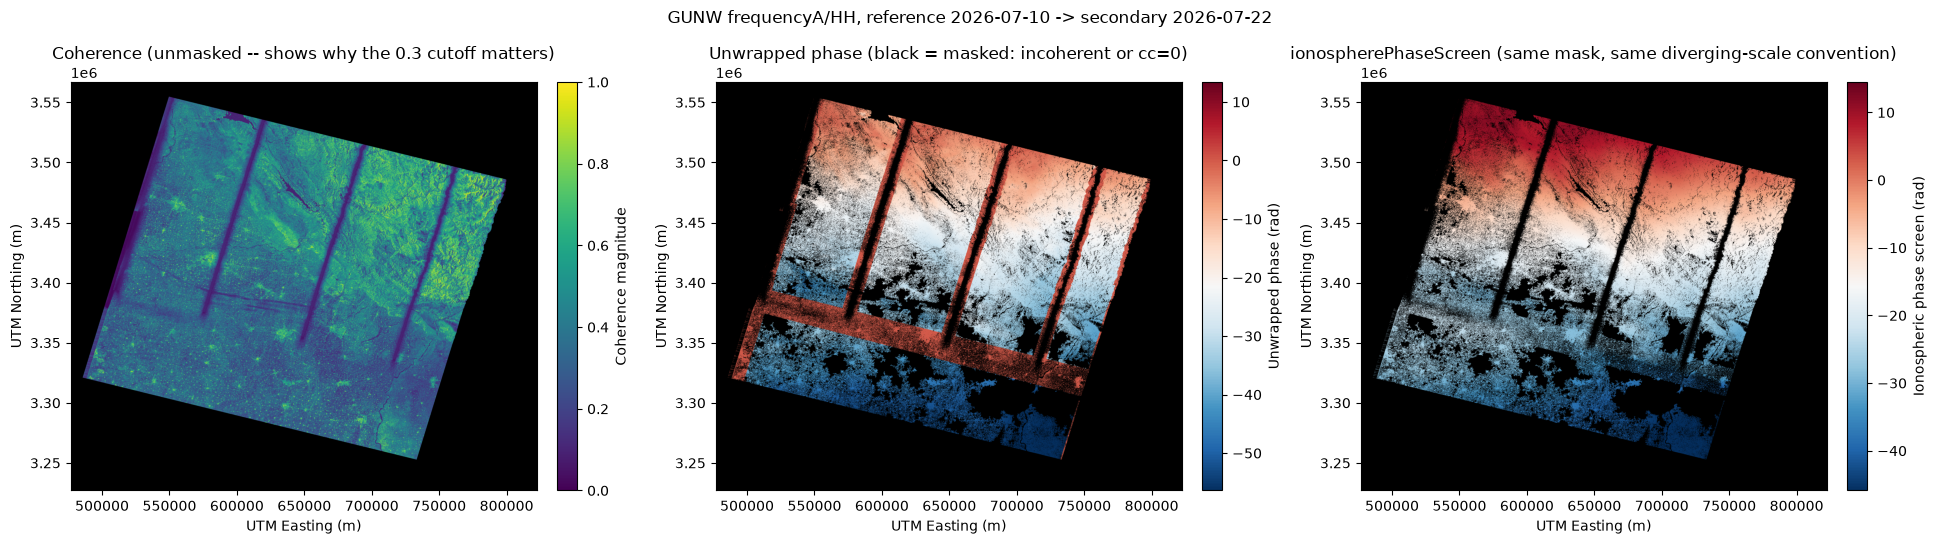

In [6]:
extent = [coords["x"].min(), coords["x"].max(), coords["y"].min(), coords["y"].max()]

fig, axes = viz.new_figure(ncols=3)
viz.imshow_masked(
    axes[0], coherence, valid_mask=None, cmap="viridis", vmin=0, vmax=1, extent=extent,
    xlabel="UTM Easting (m)", ylabel="UTM Northing (m)", colorbar_label="Coherence magnitude",
    title="Coherence (unmasked -- shows why the 0.3 cutoff matters)",
)
viz.imshow_diverging(
    axes[1], phase_valid, valid_mask=valid_mask, center=median_phase, cmap="RdBu_r", extent=extent,
    xlabel="UTM Easting (m)", ylabel="UTM Northing (m)", colorbar_label="Unwrapped phase (rad)",
    title="Unwrapped phase (black = masked: incoherent or cc=0)",
)
viz.imshow_diverging(
    axes[2], ionosphere_valid, valid_mask=valid_mask, center=median_ionosphere, cmap="RdBu_r", extent=extent,
    xlabel="UTM Easting (m)", ylabel="UTM Northing (m)", colorbar_label="Ionospheric phase screen (rad)",
    title="ionospherePhaseScreen (same mask, same diverging-scale convention)",
)
fig.suptitle("GUNW frequencyA/HH, reference 2026-07-10 -> secondary 2026-07-22")
fig.tight_layout()
plt.show()

## Interpreting this -- and a closer look at the large-scale gradient

The coherence panel shows where the interferometric phase can be trusted at all -- coherence is generally higher over stable, unvegetated or built-up terrain and lower over vegetated/agricultural areas that decorrelate over a 12-day repeat pass, and is visibly lower along a horizontal band and along several vertical (sub-swath boundary) stripes. The masked unwrapped-phase panel only shows phase where both `connectedComponents` and the coherence threshold say it's reliable; masked (black) areas are explicitly *not* claiming zero displacement -- they're pixels this technique cannot say anything about.

The masked phase panel is not visually flat, so it's worth being precise about what its large-scale pattern is (and isn't) before moving on:

In [7]:
row_means = np.nanmean(phase_valid, axis=1)
valid_rows = np.where(~np.all(np.isnan(phase_valid), axis=1))[0]
row_span = valid_rows[-1] - valid_rows[0]
print(f"Row-mean unwrapped phase (within valid_mask) ranges from {np.nanmin(row_means):.1f} to "
      f"{np.nanmax(row_means):.1f} rad across the scene's {row_span} valid azimuth lines "
      f"(~{(np.nanmax(row_means) - np.nanmin(row_means)) / row_span:.4f} rad/line on average).")
print(f"That span is ~{(np.nanmax(row_means) - np.nanmin(row_means)) / (2 * np.pi):.1f} full 2*pi cycles.")

Row-mean unwrapped phase (within valid_mask) ranges from -60.6 to 0.0 rad across the scene's 3769 valid azimuth lines (~0.0161 rad/line on average).
That span is ~9.6 full 2*pi cycles.


/tmp/ipykernel_355349/978477397.py:1: RuntimeWarning: Mean of empty slice
  row_means = np.nanmean(phase_valid, axis=1)


**Theory check (Module 00, Section 9):** `displacement = phase x wavelength / (4*pi)`. Using this file's real L-band wavelength, let's see what that gradient would mean taken at face value as ground motion:

In [8]:
gradient_span_rad = float(np.nanmax(row_means) - np.nanmin(row_means))
apparent_displacement_m = gradient_span_rad * wavelength_l / (4 * np.pi)
print(f"L-band wavelength: {wavelength_l*100:.1f} cm")
print(f"Row-mean phase gradient span: {gradient_span_rad:.1f} rad")
print(f"Taken at face value as line-of-sight displacement: {apparent_displacement_m*100:.0f} cm")
print()
print("Over a meter of apparent motion, smoothly varying across a single 12-day pair, is not")
print("plausible as real ground deformation for this kind of terrain -- which is exactly why we")
print("look for a different explanation below rather than reporting this as a displacement map.")

L-band wavelength: 24.2 cm
Row-mean phase gradient span: 60.6 rad
Taken at face value as line-of-sight displacement: 117 cm

Over a meter of apparent motion, smoothly varying across a single 12-day pair, is not
plausible as real ground deformation for this kind of terrain -- which is exactly why we
look for a different explanation below rather than reporting this as a displacement map.


### Checking against the product's own ionospheric phase screen

L-band is far more sensitive to ionospheric delay than shorter-wavelength SAR bands, because ionospheric phase delay scales with wavelength squared -- the same total electron content (TEC) along the propagation path produces a much larger phase delay at L-band than at, say, C-band. NISAR's GUNW product ships a precomputed `ionospherePhaseScreen` layer (derived via split-spectrum processing on the RSLC's own sub-bands) specifically so this can be checked directly rather than assumed. We compare it to the unwrapped phase quantitatively below, rather than relying on visual inspection alone.

In [9]:
both_valid = valid_mask & np.isfinite(phase) & np.isfinite(ionosphere)
pixel_corr = float(np.corrcoef(phase[both_valid], ionosphere[both_valid])[0, 1])

row_means_ionosphere = np.nanmean(ionosphere_valid, axis=1)
row_mask = np.isfinite(row_means) & np.isfinite(row_means_ionosphere)
row_corr = float(np.corrcoef(row_means[row_mask], row_means_ionosphere[row_mask])[0, 1])

ionosphere_gradient_span_rad = float(np.nanmax(row_means_ionosphere) - np.nanmin(row_means_ionosphere))
magnitude_ratio = ionosphere_gradient_span_rad / gradient_span_rad

print(f"Pixelwise correlation (unwrapped phase vs. ionospherePhaseScreen, valid_mask, n={both_valid.sum():,}): {pixel_corr:.2f}")
print(f"Row-mean correlation (same large-scale-gradient comparison as the apparent-displacement check above): {row_corr:.2f}")
print()
print(f"Unwrapped phase row-mean gradient span:       {gradient_span_rad:.1f} rad")
print(f"ionospherePhaseScreen row-mean gradient span: {ionosphere_gradient_span_rad:.1f} rad")
print(f"Ratio (ionosphere span / phase span):         {magnitude_ratio:.2f}")
print()

# Illustrative frequency-squared comparison, using this file's own L-band wavelength (from center_frequency())
# against a typical C-band wavelength (e.g. Sentinel-1, ~5.6 cm) -- for context only, not this file's own number.
c_band_wavelength_m = 0.056
ionospheric_sensitivity_ratio = (wavelength_l / c_band_wavelength_m) ** 2
print(f"This file's L-band wavelength (from center_frequency()): {wavelength_l*100:.1f} cm")
print(f"Ionospheric delay ~ wavelength^2, so at this wavelength the same TEC produces ~"
      f"{ionospheric_sensitivity_ratio:.0f}x more phase delay than a typical {c_band_wavelength_m*100:.1f} cm C-band acquisition would see.")

Pixelwise correlation (unwrapped phase vs. ionospherePhaseScreen, valid_mask, n=5,853,659): 0.68
Row-mean correlation (same large-scale-gradient comparison as the apparent-displacement check above): 0.93

Unwrapped phase row-mean gradient span:       60.6 rad
ionospherePhaseScreen row-mean gradient span: 61.7 rad
Ratio (ionosphere span / phase span):         1.02

This file's L-band wavelength (from center_frequency()): 24.2 cm
Ionospheric delay ~ wavelength^2, so at this wavelength the same TEC produces ~19x more phase delay than a typical 5.6 cm C-band acquisition would see.


/tmp/ipykernel_355349/3621527970.py:4: RuntimeWarning: Mean of empty slice
  row_means_ionosphere = np.nanmean(ionosphere_valid, axis=1)


1. **A smooth, large-scale gradient** across the scene, broadly correlated with position along the frame -- which, per Modules 01-02, spans real elevation relief from agricultural plains to Himalayan foothills. A gradient this large and this smooth (see the apparent-displacement check above) is far too large to represent localized ground deformation from a single 12-day pair. Checked quantitatively against this product's own `ionospherePhaseScreen` layer above, the row-mean correlation between it and the unwrapped phase is r ~= 0.93 (pixelwise r ~= 0.68 across all valid pixels), and the ionospheric screen's own row-mean gradient span (~61.7 rad) is essentially the same magnitude as the unwrapped phase's (~60.6 rad, ratio ~1.02). That is a strong, quantitative match, not just a visual coincidence -- so this gradient is **consistent with ionospheric phase contribution, per the ionospherePhaseScreen layer**, rather than a generic "atmospheric/orbital ramp." This makes physical sense: ionospheric phase delay scales with wavelength squared, and this file's own L-band wavelength (24.2 cm, from `center_frequency()`) is roughly 19x more sensitive to a given ionospheric total electron content than a typical C-band acquisition (~5.6 cm) would be -- L-band InSAR is specifically exposed to this error source in a way shorter-wavelength SAR is not. The pixelwise correlation being well below the row-mean correlation also means the ionosphere doesn't explain *everything* at full pixel resolution -- some smaller-scale residual (plausibly tropospheric delay, or coherence/unwrapping noise) rides on top of the dominant ionospheric signal. A single interferogram pair still cannot fully separate these; that requires an external atmospheric model, elevation-correlation regression, or a multi-interferogram time series (see closing cell).
2. **A sharper, more localized jump** coincident with the low-coherence horizontal band visible in the coherence panel -- consistent with the unwrapping algorithm having a harder time bridging a decorrelated strip, not a real ground-motion step. This is exactly the kind of feature coherence/connected-components masking is meant to flag.

The large-scale gradient (item 1) is now a quantitatively-supported finding, not a guess -- but it is still not a validated deformation measurement, and item 2 remains an unwrapping-artifact hypothesis rather than a confirmed one. This general workflow (read unwrapped phase + coherence + connected components, mask, visualize, then check the large-scale pattern against the product's own ionospheric-screen layer) is the starting point for subsidence, coseismic, or glacier-motion monitoring with InSAR -- the additional steps needed to actually trust a displacement estimate are in the closing cell below.

In [10]:
gunw.close()

## What real-world deployment would additionally require

- A validated event date/window (earthquake catalog, subsidence monitoring program, glacier survey, etc.) to justify interpreting this particular interferogram pair as deformation-relevant in the first place.
- Conversion from phase to physical displacement (phase x wavelength / 4*pi along the line of sight), referenced to a known-stable ground control point -- not attempted here, since no such reference point has been validated for this scene.
- **Ionospheric phase correction, specifically** -- shown above to be the dominant contributor to this scene's large-scale gradient (r ~= 0.93 row-mean correlation with `ionospherePhaseScreen`, matching its magnitude to within ~2%), not a generic "atmospheric" catch-all. Any real L-band InSAR deformation workflow must subtract this layer (or apply an equivalent split-spectrum / GIM-TEC-based correction) before the phase can be trusted as deformation-relevant -- L-band's longer wavelength makes it specifically more exposed to this than C-band or X-band InSAR, per the wavelength-squared scaling shown above. This notebook computes the correlation as a diagnostic but does not apply the correction.
- A smaller residual tropospheric delay correction is also likely needed on top of the ionospheric one (the pixelwise correlation, r ~= 0.68, is well below the row-mean correlation, implying the ionosphere doesn't explain everything at full resolution) -- typically via an external weather model or elevation-correlation regression.
- A longer InSAR time series (many interferogram pairs, time-series inversion) rather than a single pair, to separate genuine secular/coseismic deformation from atmospheric noise and to unwrap through low-coherence periods.
- Ground truth (GNSS, leveling, or field survey data) to validate any displacement estimate before acting on it.